## Setup for  LSTM

In [1]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# this for time series
#import statsmodels.formula.api as smf
#from statsmodels.tsa.seasonal import seasonal_decompose
#from scipy.ndimage import gaussian_filter
#from calendar import monthrange
#from calendar import month_name
#from sklearn.metrics import mean_squared_error
#from math import sqrt
#from statsmodels.tsa.stattools import adfuller,kpss
#from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.arima_model import ARIMA
#from statsmodels.graphics.tsaplots import plot_pacf
#from pmdarima.arima import auto_arima
#import statsmodels.graphics.tsaplots as tsaplot
#from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

#import tensorflow as tf
#from keras.models import Sequential
#from keras.layers import LSTM, Dense

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import load_model
import time


In [2]:
#pip install --upgrade pip
#%pip install keras
#%pip install tensorflow 

### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [3]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [4]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [5]:
#res_df.dtypes

In [6]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [7]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [8]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [9]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [10]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [11]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [12]:
data_df_gwh = data_df_mwh.copy()

In [13]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [14]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [15]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [16]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [17]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [18]:

data_df= data_df_gwh.copy()

In [19]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [20]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [21]:
##data_df.columns

In [22]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [23]:
#### Potential targets  (It corresponds to the rename column names.)
#string = 'Himesh_not_good'
#name = string.split('_')[0]
#separated_string = string.split('_')
#print(separated_string[0]) # Output: Himesh_not


#title_main = 'Energy generation in GWh ' # General title of plots files
main_0  = 'Total_energy_generation_gwh'
title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Total energy generation in GWh
Total energy generation(GWh)


### Here we set the function for line plot  

In [24]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



In [25]:
## Energy development over year (time)
#fig, ax = plt.subplots()
#sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
#ax.set(title=title_main, ylabel= ylable_target);

In [26]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [27]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [28]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

In [29]:
#average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [30]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [31]:
#catplot
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    cat_data_df = data_df \
#    .groupby(['Date', 'Year'], as_index=False)\
#    .agg({col: np.sum}) \
#    .set_index('Date')
#    #sns.lineplot(data=cat_data_df[col])
#    sns.lineplot(x='Date', y=col, data=cat_data_df)
#    #ylable_00  = col.replace('_gwh', '(GWh)')
#    #ylable_target0  = ylable_00.replace('_', ' ')
#   # ax.set(title=col.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
#    plt.xticks(rotation=45)
#    plt.tight_layout()


In [32]:
# Aggregate Energy_mwh or Solar_mwh by day
#daily_data_df = data_df \
#    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
#    .agg({target: np.sum}) \
#    .set_index('Date')

In [33]:
#daily_data_df

In [34]:
dfs = data_df[['Date',  target]]

#### New test

In [ ]:
# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Create dataframe
data = dfs.sort_values(by='Date', ascending=True)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
new_data['Date'] = data['Date'].values
new_data[target] = data[target].values

# Redefine the number of input time sequential steps
num = 4

# Set index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Create train and test sets with time-based splitting
train_size = int(len(new_data) * 0.8)
train, valid = new_data.iloc[:train_size], new_data.iloc[train_size:]

# Separate the features and target variable
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
valid_scaled = scaler.transform(valid)

X_train, y_train = [], []
for i in range(num, len(train_scaled)):
    X_train.append(train_scaled[i - num:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
history = []
val_losses = []
for train_index, test_index in tscv.split(X_train):
    X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    h = model.fit(X_train_cv, y_train_cv, epochs=4, batch_size=1, verbose=2)
    history.append(h.history['loss'])
    val_loss = model.evaluate(X_test_cv, y_test_cv, verbose=0)
    val_losses.append(val_loss)

# Predict on the validation set
inputs = valid_scaled[len(valid_scaled) - num:]
X_test = np.array([inputs])

closing_price = []
for _ in range(len(valid_scaled)):
    predicted = model.predict(X_test)
    closing_price.append(predicted[0][0])
    X_test = np.roll(X_test, -1)
    X_test[0, -1] = predicted

# Inverse transform predictions and original values
closing_price = np.array(closing_price).reshape(-1, 1)
closing_price = scaler.inverse_transform(closing_price)

y_true = scaler.inverse_transform(valid_scaled)[:, 0]

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
rmse = np.sqrt(mean_squared_error(y_true, closing_price))
mse = mean_squared_error(y_true, closing_price)
mae = mean_absolute_error(y_true, closing_price)
r2 = r2_score(y_true, closing_price)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the training loss and validation loss versus epoch curve
losses = np.mean(np.array(history), axis=0)
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Mean Loss')
plt.plot(np.array(val_losses).mean(axis=0), label='Mean Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Loss vs. Epoch')
plt.legend()
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:train_size], train[target], 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid[target], 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_13673/4123439023.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/4
9984/9984 - 38s - loss: 0.0063 - 38s/epoch - 4ms/step
Epoch 2/4
9984/9984 - 34s - loss: 0.0052 - 34s/epoch - 3ms/step
Epoch 3/4
9984/9984 - 33s - loss: 0.0050 - 33s/epoch - 3ms/step
Epoch 4/4
9984/9984 - 34s - loss: 0.0049 - 34s/epoch - 3ms/step
Epoch 1/4
19967/19967 - 69s - loss: 0.0051 - 69s/epoch - 3ms/step
Epoch 2/4
19967/19967 - 67s - loss: 0.0050 - 67s/epoch - 3ms/step
Epoch 3/4
19967/19967 - 69s - loss: 0.0050 - 69s/epoch - 3ms/step
Epoch 4/4
19967/19967 - 71s - loss: 0.0049 - 71s/epoch - 4ms/step
Epoch 1/4
29950/29950 - 102s - loss: 0.0050 - 102s/epoch - 3ms/step
Epoch 2/4
29950/29950 - 101s - loss: 0.0049 - 101s/epoch - 3ms/step
Epoch 3/4
29950/29950 - 101s - loss: 0.0048 - 101s/epoch - 3ms/step
Epoch 4/4
29950/29950 - 100s - loss: 0.0048 - 100s/epoch - 3ms/step
Epoch 1/4
39933/39933 - 42s - loss: 0.0048 - 42s/epoch - 1ms/step
Epoch 2/4
39933/39933 - 45s - loss: 0.0047 - 45s/epoch - 1ms/step
Epoch 3/4
39933/39933 - 48s - loss: 0.0046 - 48s/epoch - 1ms/step
Epoch 4/4


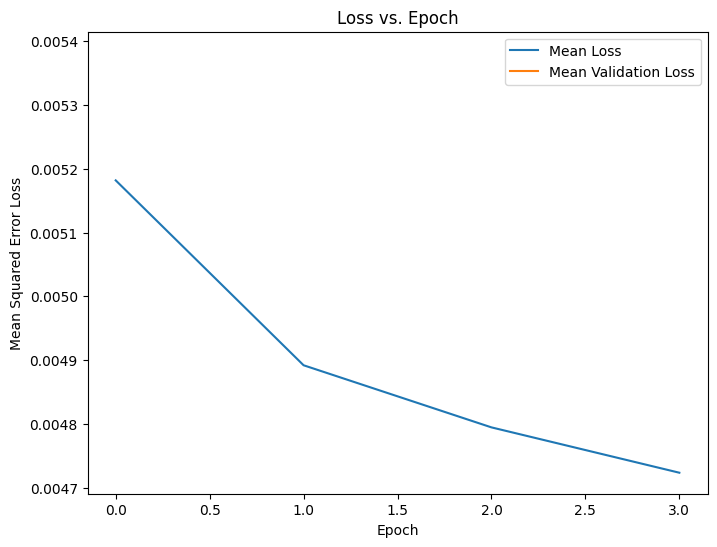

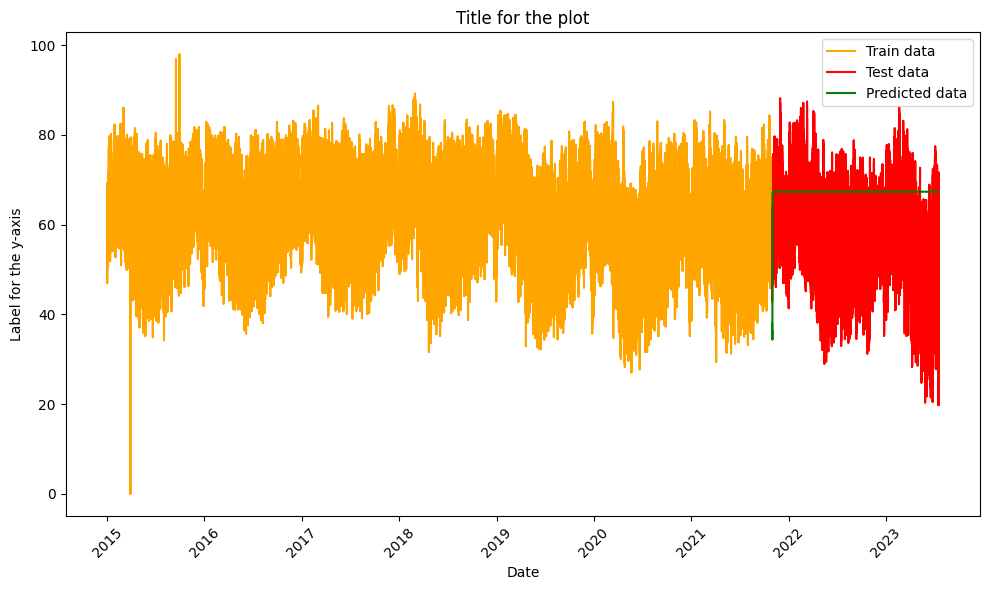

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Create dataframe
data = dfs.sort_values(by='Date', ascending=True)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
new_data['Date'] = data['Date'].values
new_data[target] = data[target].values

# Redefine the number of input time sequential steps
num = 4

# Set index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Create train and test sets with time-based splitting
train_size = int(len(new_data) * 0.8)
train, valid = new_data.iloc[:train_size], new_data.iloc[train_size:]

# Separate the features and target variable
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
valid_scaled = scaler.transform(valid)

X_train, y_train = [], []
for i in range(num, len(train_scaled)):
    X_train.append(train_scaled[i - num:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
history = []
val_losses = []
for train_index, test_index in tscv.split(X_train):
    X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    h = model.fit(X_train_cv, y_train_cv, epochs=4, batch_size=1, verbose=2)
    history.append(h.history['loss'])
    val_loss = model.evaluate(X_test_cv, y_test_cv, verbose=0)
    val_losses.append(val_loss)

# Predict on the validation set
inputs = valid_scaled[len(valid_scaled) - num:]
X_test = np.array([inputs])

closing_price = []
for _ in range(len(valid_scaled)):
    predicted = model.predict(X_test)
    closing_price.append(predicted[0][0])
    X_test = np.roll(X_test, -1)
    X_test[0, -1] = predicted

# Inverse transform predictions and original values
closing_price = np.array(closing_price).reshape(-1, 1)
closing_price = scaler.inverse_transform(closing_price)

y_true = scaler.inverse_transform(valid_scaled)[:, 0]

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
rmse = np.sqrt(mean_squared_error(y_true, closing_price))
mse = mean_squared_error(y_true, closing_price)
mae = mean_absolute_error(y_true, closing_price)
r2 = r2_score(y_true, closing_price)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the training loss and validation loss versus epoch curve
losses = np.mean(np.array(history), axis=0)
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Mean Loss')
plt.plot(np.array(val_losses).mean(axis=0), label='Mean Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Loss vs. Epoch')
plt.legend()
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:train_size], train[target], 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid[target], 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_99962/23115154.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/60
999/999 - 8s - loss: 0.0086 - 8s/epoch - 8ms/step
Epoch 2/60
999/999 - 7s - loss: 0.0050 - 7s/epoch - 7ms/step
Epoch 3/60
999/999 - 7s - loss: 0.0045 - 7s/epoch - 7ms/step
Epoch 4/60
999/999 - 6s - loss: 0.0045 - 6s/epoch - 6ms/step
Epoch 5/60
999/999 - 6s - loss: 0.0044 - 6s/epoch - 6ms/step
Epoch 6/60
999/999 - 6s - loss: 0.0043 - 6s/epoch - 6ms/step
Epoch 7/60
999/999 - 6s - loss: 0.0043 - 6s/epoch - 6ms/step
Epoch 8/60
999/999 - 6s - loss: 0.0042 - 6s/epoch - 6ms/step
Epoch 9/60
999/999 - 6s - loss: 0.0041 - 6s/epoch - 6ms/step
Epoch 10/60
999/999 - 6s - loss: 0.0041 - 6s/epoch - 6ms/step
Epoch 11/60
999/999 - 6s - loss: 0.0041 - 6s/epoch - 6ms/step
Epoch 12/60
999/999 - 6s - loss: 0.0040 - 6s/epoch - 6ms/step
Epoch 13/60
999/999 - 6s - loss: 0.0039 - 6s/epoch - 6ms/step
Epoch 14/60
999/999 - 6s - loss: 0.0039 - 6s/epoch - 6ms/step
Epoch 15/60
999/999 - 6s - loss: 0.0039 - 6s/epoch - 6ms/step
Epoch 16/60
999/999 - 6s - loss: 0.0038 - 6s/epoch - 6ms/step
Epoch 17/60
999/9

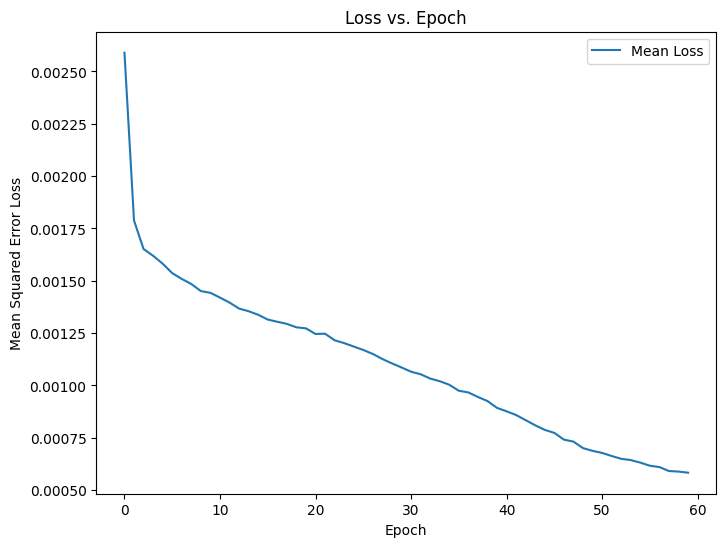

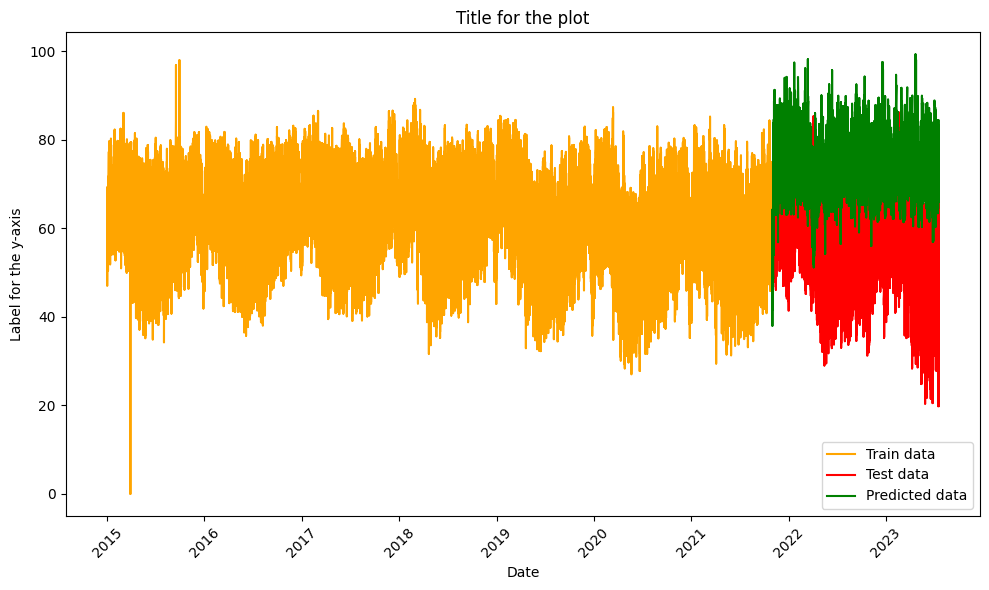

In [34]:
# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Create dataframe
data = dfs.sort_values(by='Date', ascending=True)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
new_data['Date'] = data['Date'].values
new_data[target] = data[target].values

# Redefine number of input time sequential steps
num = 24

# Set index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Create train and test sets with time-based splitting
train_size = int(len(new_data) * 0.8)
train, valid = new_data.iloc[:train_size], new_data.iloc[train_size:]

# Separate the features and target variable
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
valid_scaled = scaler.transform(valid)

X_train, y_train = [], []
for i in range(num, len(train_scaled)):
    X_train.append(train_scaled[i - num:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
history = []
for train_index, test_index in tscv.split(X_train):
    X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    h = model.fit(X_train_cv, y_train_cv, epochs=60, batch_size=10, verbose=2)
    history.append(h.history['loss'])

# Predict on the validation set
inputs = valid_scaled[len(valid_scaled) - num:]
X_test = np.array([inputs])

closing_price = []
for _ in range(len(valid_scaled)):
    predicted = model.predict(X_test)
    closing_price.append(predicted[0][0])
    X_test = np.roll(X_test, -1)
    X_test[0, -1] = predicted

# Inverse transform predictions and original values
closing_price = np.array(closing_price).reshape(-1, 1)
closing_price = scaler.inverse_transform(closing_price)

y_true = scaler.inverse_transform(valid_scaled)[:, 0]

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
rmse = np.sqrt(mean_squared_error(y_true, closing_price))
mse = mean_squared_error(y_true, closing_price)
mae = mean_absolute_error(y_true, closing_price)
r2 = r2_score(y_true, closing_price)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the loss versus epoch curve
losses = np.mean(np.array(history), axis=0)
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Mean Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Loss vs. Epoch')
plt.legend()
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:train_size], train[target], 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid[target], 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

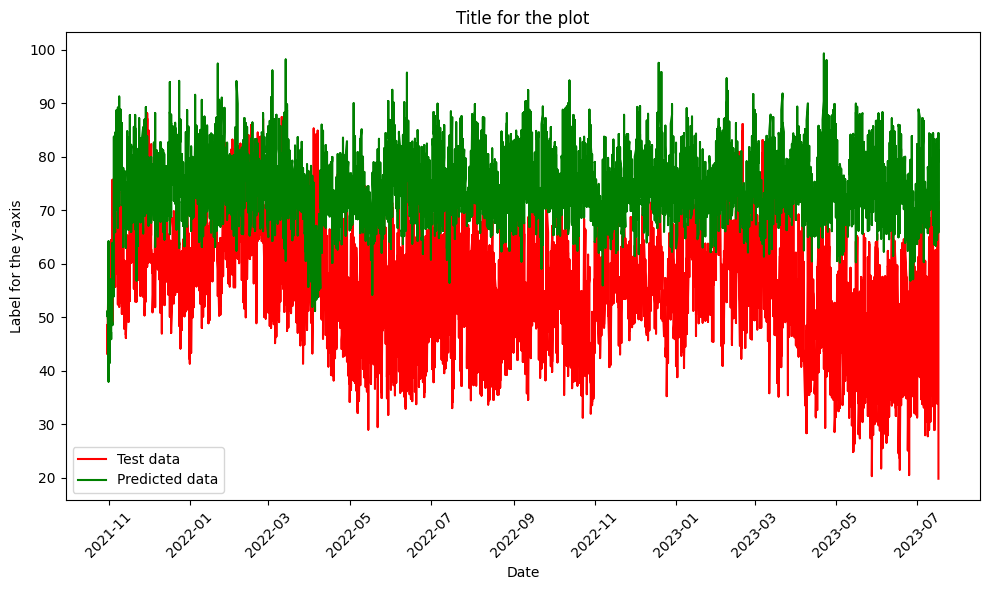

In [35]:
# Plot the results
plt.figure(figsize=(10, 6))
#plt.plot(data['Date'][:train_size], train[target], 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid[target], 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [36]:
# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Create dataframe
data = dfs.sort_values(by='Date', ascending=True)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
new_data['Date'] = data['Date'].values
new_data[target] = data[target].values

# Redefine number of input time sequential steps
num = 24

# Set index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Create train and test sets with time-based splitting
train_size = int(len(new_data) * 0.8)
train, valid = new_data.iloc[:train_size], new_data.iloc[train_size:]

# Separate the features and target variable
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
valid_scaled = scaler.transform(valid)

X_train, y_train = [], []
for i in range(num, len(train_scaled)):
    X_train.append(train_scaled[i - num:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
history = []
for train_index, test_index in tscv.split(X_train):
    X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    h = model.fit(X_train_cv, y_train_cv, epochs=100, batch_size=10, verbose=2)
    history.append(h.history['loss'])

# Predict on the validation set
inputs = valid_scaled[len(valid_scaled) - num:]
X_test = np.array([inputs])

closing_price = []
for _ in range(len(valid_scaled)):
    predicted = model.predict(X_test)
    closing_price.append(predicted[0][0])
    X_test = np.roll(X_test, -1)
    X_test[0, -1] = predicted

# Inverse transform predictions and original values
closing_price = np.array(closing_price).reshape(-1, 1)
closing_price = scaler.inverse_transform(closing_price)

y_true = scaler.inverse_transform(valid_scaled)[:, 0]

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
rmse = np.sqrt(mean_squared_error(y_true, closing_price))
mse = mean_squared_error(y_true, closing_price)
mae = mean_absolute_error(y_true, closing_price)
r2 = r2_score(y_true, closing_price)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the loss versus epoch curve
losses = np.mean(np.array(history), axis=0)
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Mean Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Loss vs. Epoch')
plt.legend()
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:train_size], train[target], 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid[target], 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_99962/2477392604.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/100
999/999 - 8s - loss: 0.0086 - 8s/epoch - 8ms/step
Epoch 2/100
999/999 - 7s - loss: 0.0047 - 7s/epoch - 7ms/step
Epoch 3/100
999/999 - 7s - loss: 0.0046 - 7s/epoch - 7ms/step
Epoch 4/100
999/999 - 6s - loss: 0.0045 - 6s/epoch - 6ms/step
Epoch 5/100
999/999 - 6s - loss: 0.0044 - 6s/epoch - 6ms/step
Epoch 6/100
999/999 - 7s - loss: 0.0043 - 7s/epoch - 7ms/step
Epoch 7/100
999/999 - 6s - loss: 0.0042 - 6s/epoch - 6ms/step
Epoch 8/100
999/999 - 7s - loss: 0.0042 - 7s/epoch - 7ms/step
Epoch 9/100
999/999 - 7s - loss: 0.0042 - 7s/epoch - 7ms/step
Epoch 10/100
999/999 - 7s - loss: 0.0041 - 7s/epoch - 7ms/step
Epoch 11/100
999/999 - 7s - loss: 0.0040 - 7s/epoch - 7ms/step
Epoch 12/100
999/999 - 7s - loss: 0.0040 - 7s/epoch - 7ms/step
Epoch 13/100
999/999 - 7s - loss: 0.0040 - 7s/epoch - 7ms/step
Epoch 14/100
999/999 - 7s - loss: 0.0039 - 7s/epoch - 7ms/step
Epoch 15/100
999/999 - 7s - loss: 0.0039 - 7s/epoch - 7ms/step
Epoch 16/100
999/999 - 7s - loss: 0.0038 - 7s/epoch - 7ms/step
E

KeyboardInterrupt: 

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_80416/512190911.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/10
4993/4993 - 13s - loss: 0.0020 - 13s/epoch - 3ms/step
Epoch 2/10
4993/4993 - 10s - loss: 4.5623e-04 - 10s/epoch - 2ms/step
Epoch 3/10
4993/4993 - 10s - loss: 4.2488e-04 - 10s/epoch - 2ms/step
Epoch 4/10
4993/4993 - 11s - loss: 3.9120e-04 - 11s/epoch - 2ms/step
Epoch 5/10
4993/4993 - 10s - loss: 3.7745e-04 - 10s/epoch - 2ms/step
Epoch 6/10
4993/4993 - 10s - loss: 3.5746e-04 - 10s/epoch - 2ms/step
Epoch 7/10
4993/4993 - 10s - loss: 3.5494e-04 - 10s/epoch - 2ms/step
Epoch 8/10
4993/4993 - 10s - loss: 3.5724e-04 - 10s/epoch - 2ms/step
Epoch 9/10
4993/4993 - 10s - loss: 3.2900e-04 - 10s/epoch - 2ms/step
Epoch 10/10
4993/4993 - 11s - loss: 3.2188e-04 - 11s/epoch - 2ms/step
Epoch 1/10
9984/9984 - 21s - loss: 2.9162e-04 - 21s/epoch - 2ms/step
Epoch 2/10
9984/9984 - 21s - loss: 2.7586e-04 - 21s/epoch - 2ms/step
Epoch 3/10
9984/9984 - 21s - loss: 2.6945e-04 - 21s/epoch - 2ms/step
Epoch 4/10
9984/9984 - 21s - loss: 2.5863e-04 - 21s/epoch - 2ms/step
Epoch 5/10
9984/9984 - 22s - loss: 2.

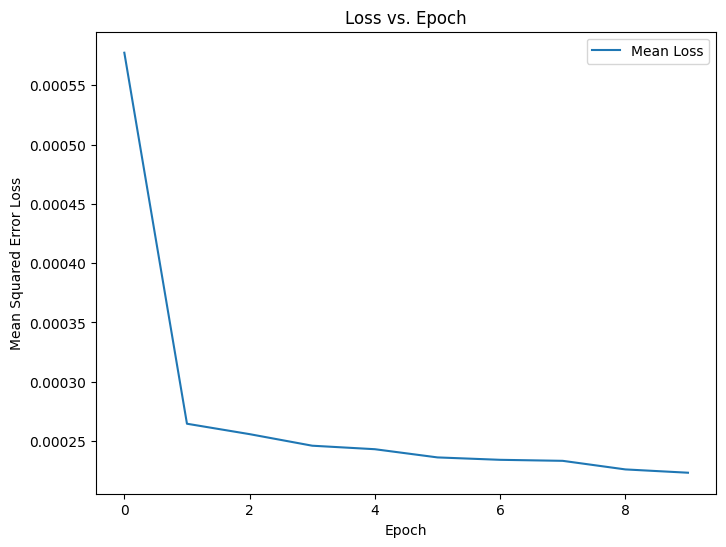

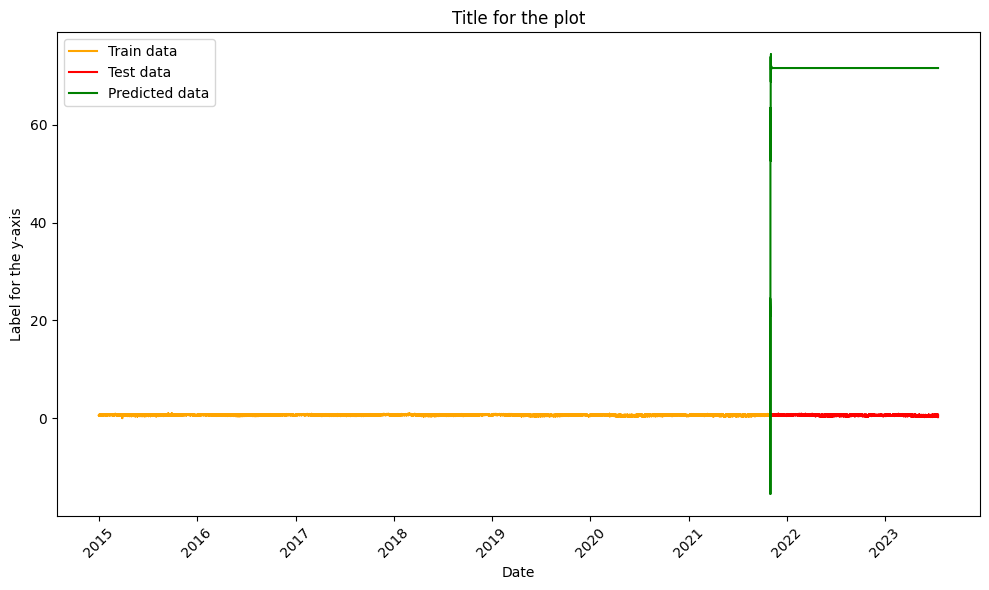

In [108]:
# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Creating dataframe
data = dfs.sort_values(by='Date', ascending=True)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
for i in range(0, len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# Redefine num= 
#Input Sequence Length: The purpose of num is to determine the length of the input sequences that will be fed into the LSTM model during training.
num = 7

# Setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Create train and test sets with time-based splitting
train_size = int(len(new_data) * 0.8)
train, valid = new_data.iloc[:train_size], new_data.iloc[train_size:]

# Separate the features and target variable
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
valid_scaled = scaler.transform(valid)

X_train, y_train = [], []
for i in range(num, len(train_scaled)):
    X_train.append(train_scaled[i - num:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
history = []
for train_index, test_index in tscv.split(X_train):
    X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    h = model.fit(X_train_cv, y_train_cv, epochs=10, batch_size=2, verbose=2)
    history.append(h.history['loss'])

# Predict on the validation set
inputs = valid_scaled[len(valid_scaled) - num:]
X_test = np.array([inputs])

closing_price = []
for _ in range(len(valid_scaled)):
    predicted = model.predict(X_test)
    closing_price.append(predicted[0][0])
    X_test = np.roll(X_test, -1)
    X_test[0, -1] = predicted

# Inverse transform predictions and original values
closing_price = np.array(closing_price).reshape(-1, 1)
closing_price = scaler.inverse_transform(closing_price)

y_true = scaler.inverse_transform(valid_scaled)[:, 0]

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
rmse = np.sqrt(mean_squared_error(y_true, closing_price))
mse = mean_squared_error(y_true, closing_price)
mae = mean_absolute_error(y_true, closing_price)
r2 = r2_score(y_true, closing_price)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the loss versus epoch curve
losses = np.mean(np.array(history), axis=0)
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Mean Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Loss vs. Epoch')
plt.legend()
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:train_size], train_scaled, 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid_scaled, 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


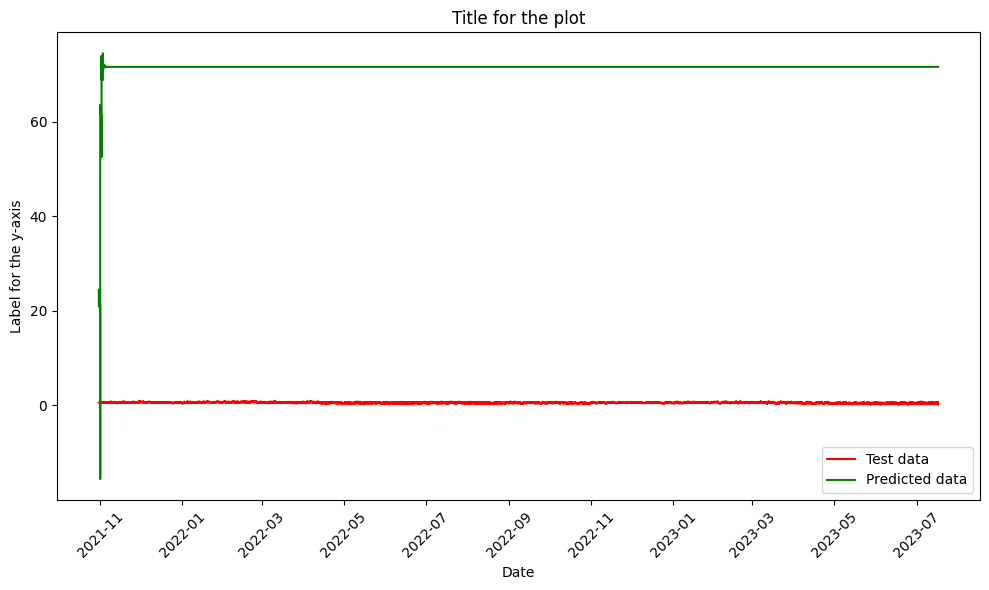

In [109]:
# Plot the results
plt.figure(figsize=(10, 6))
#plt.plot(data['Date'][:train_size], train_scaled, 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid_scaled, 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
#above to it 27.07.2023 look above this cell

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_80416/3832554451.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


Epoch 1/30
999/999 - 19s - loss: 0.0076 - 19s/epoch - 19ms/step
Epoch 2/30
999/999 - 12s - loss: 0.0048 - 12s/epoch - 12ms/step
Epoch 3/30
999/999 - 12s - loss: 0.0046 - 12s/epoch - 12ms/step
Epoch 4/30
999/999 - 12s - loss: 0.0045 - 12s/epoch - 12ms/step
Epoch 5/30
999/999 - 12s - loss: 0.0045 - 12s/epoch - 12ms/step
Epoch 6/30
999/999 - 12s - loss: 0.0044 - 12s/epoch - 12ms/step
Epoch 7/30
999/999 - 12s - loss: 0.0043 - 12s/epoch - 12ms/step
Epoch 8/30
999/999 - 12s - loss: 0.0042 - 12s/epoch - 12ms/step
Epoch 9/30
999/999 - 14s - loss: 0.0042 - 14s/epoch - 14ms/step
Epoch 10/30
999/999 - 14s - loss: 0.0041 - 14s/epoch - 14ms/step
Epoch 11/30
999/999 - 15s - loss: 0.0041 - 15s/epoch - 15ms/step
Epoch 12/30
999/999 - 13s - loss: 0.0040 - 13s/epoch - 13ms/step
Epoch 13/30
999/999 - 12s - loss: 0.0041 - 12s/epoch - 12ms/step
Epoch 14/30
999/999 - 13s - loss: 0.0040 - 13s/epoch - 13ms/step
Epoch 15/30
999/999 - 13s - loss: 0.0040 - 13s/epoch - 13ms/step
Epoch 16/30
999/999 - 13s - loss: 

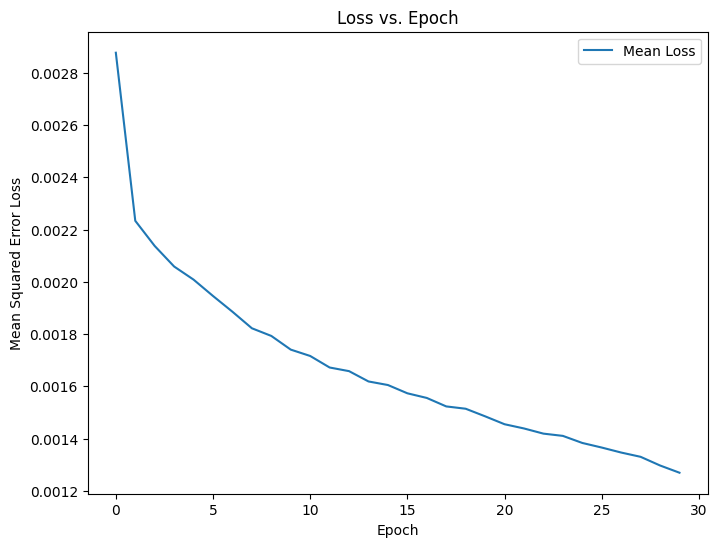

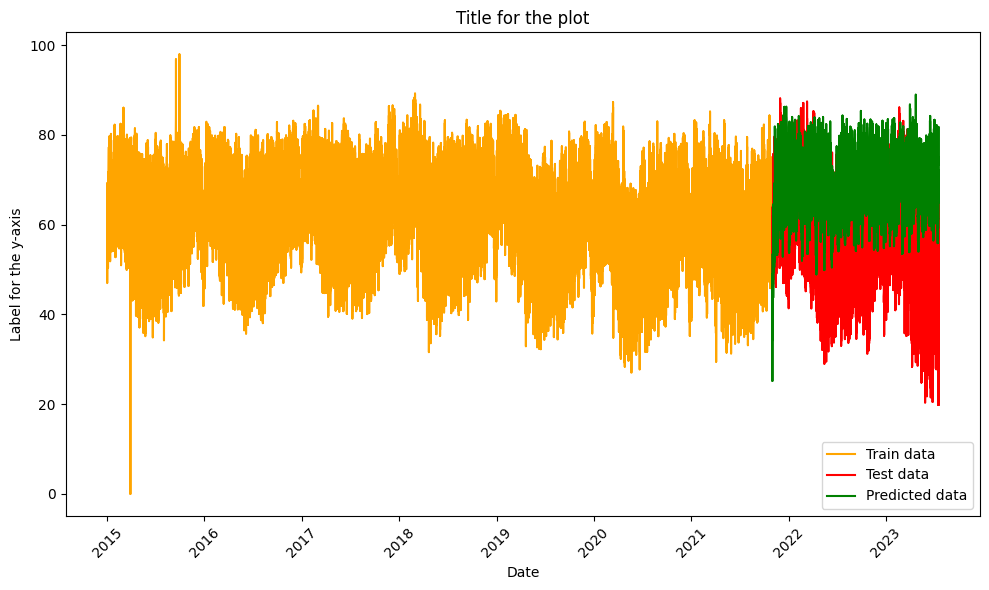

In [144]:
# Assuming you have already defined 'data_df' and 'target' variables
dfs = data_df[['Date', target]]

# Convert the 'Date' column to datetime type
dfs['Date'] = pd.to_datetime(dfs['Date'])

# Create dataframe
data = dfs.sort_values(by='Date', ascending=True)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
new_data['Date'] = data['Date'].values
new_data[target] = data[target].values

# Redefine num= 5 original
num = 24

# Set index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Create train and test sets with time-based splitting
train_size = int(len(new_data) * 0.8)
train, valid = new_data.iloc[:train_size], new_data.iloc[train_size:]

# Separate the features and target variable
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)
valid_scaled = scaler.transform(valid)

X_train, y_train = [], []
for i in range(num, len(train_scaled)):
    X_train.append(train_scaled[i - num:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
history = []
for train_index, test_index in tscv.split(X_train):
    X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    h = model.fit(X_train_cv, y_train_cv, epochs=30, batch_size=10, verbose=2)
    history.append(h.history['loss'])

# Predict on the validation set
inputs = valid_scaled[len(valid_scaled) - num:]
X_test = np.array([inputs])

closing_price = []
for _ in range(len(valid_scaled)):
    predicted = model.predict(X_test)
    closing_price.append(predicted[0][0])
    X_test = np.roll(X_test, -1)
    X_test[0, -1] = predicted

# Inverse transform predictions and original values
closing_price = np.array(closing_price).reshape(-1, 1)
closing_price = scaler.inverse_transform(closing_price)

y_true = scaler.inverse_transform(valid_scaled)[:, 0]

# Calculate evaluation metrics (RMSE, MSE, MAE, R2)
rmse = np.sqrt(mean_squared_error(y_true, closing_price))
mse = mean_squared_error(y_true, closing_price)
mae = mean_absolute_error(y_true, closing_price)
r2 = r2_score(y_true, closing_price)

print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plot the loss versus epoch curve
losses = np.mean(np.array(history), axis=0)
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Mean Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Loss vs. Epoch')
plt.legend()
plt.show()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data['Date'][:train_size], train[target], 'orange', label='Train data')
plt.plot(data['Date'][train_size:], valid[target], 'red', label='Test data')
plt.plot(data['Date'][train_size:], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title for the plot')  # Replace 'Title for the plot' with your desired title
plt.ylabel('Label for the y-axis')  # Replace 'Label for the y-axis' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

Epoch 1/50
2340/2340 [==============================] - 17s 7ms/step - loss: 0.0070
Epoch 2/50
2340/2340 [==============================] - 15s 7ms/step - loss: 0.0057
Epoch 3/50
2340/2340 [==============================] - 15s 6ms/step - loss: 0.0056
Epoch 4/50
2340/2340 [==============================] - 15s 6ms/step - loss: 0.0055
Epoch 5/50
2340/2340 [==============================] - 15s 6ms/step - loss: 0.0054
Epoch 6/50
2340/2340 [==============================] - 15s 7ms/step - loss: 0.0054
Epoch 7/50
2340/2340 [==============================] - 16s 7ms/step - loss: 0.0053
Epoch 8/50
2340/2340 [==============================] - 16s 7ms/step - loss: 0.0050
Epoch 9/50
2340/2340 [==============================] - 15s 7ms/step - loss: 0.0046
Epoch 10/50
2340/2340 [==============================] - 15s 7ms/step - loss: 0.0042
Epoch 11/50
2340/2340 [==============================] - 15s 6ms/step - loss: 0.0040
Epoch 12/50
2340/2340 [==============================] - 15s 6ms/step - lo

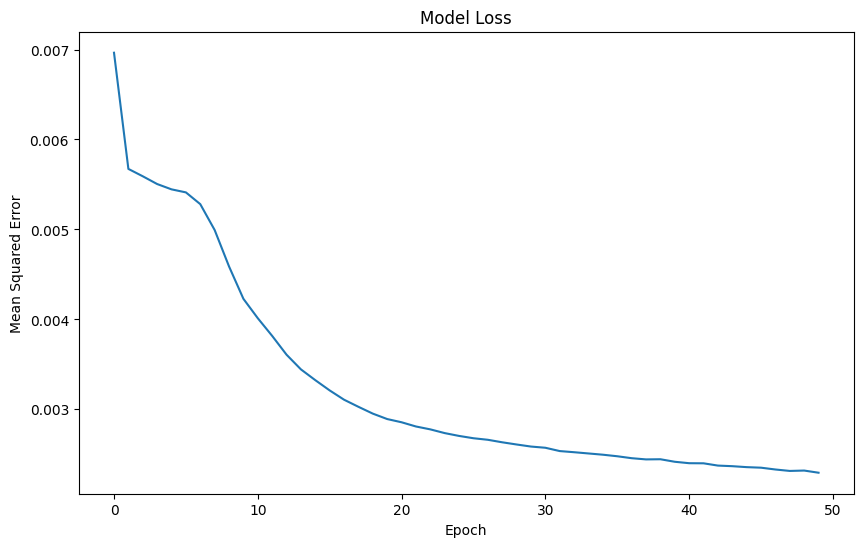

468/468 [==============================] - 2s 2ms/step
Root Mean Squared Error: 56.708083378236445
Mean Squared Error: 3215.806720433017
Mean Absolute Error: 55.78828749808252
R^2: -240866.19292696594


ValueError: Expected 2D array, got 1D array instead:
array=[0.44017985 0.5972599  0.54476208 ... 0.43626797 0.66120245 0.20237673].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

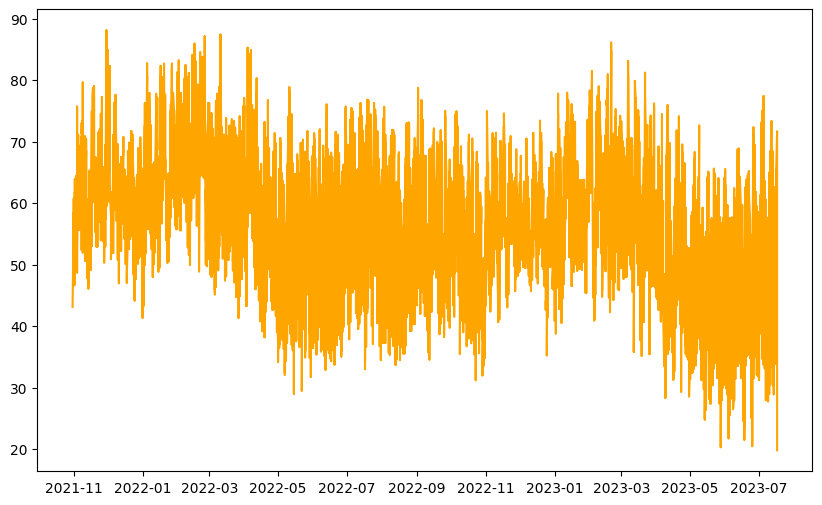

In [35]:

# Replace 'target' with the actual column name of the target variable in your dataset
#target = 'your_target_column_name'

# Assuming you have already loaded the data_df DataFrame

# Sorting the data by date
data_df = data_df.sort_values(by='Date')

# Create a new DataFrame with only the 'Date' and target columns
dfs = data_df[['Date', target]]

# Redefine num = 60 as the original value
num = 7

# Create a DataFrame with just the target column and use the date as the index
new_data = dfs.set_index('Date')

# Normalize the entire data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(new_data)

# Create sequences for training data
x_train, y_train = [], []
for i in range(num, len(scaled_data)):
    x_train.append(scaled_data[i - num:i, 0])
    y_train.append(scaled_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=100, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=100))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
history = model.fit(x_train, y_train, epochs=50, batch_size=32, verbose=1)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.show()

# Prepare the test data
x_test, y_test = [], []
for i in range(len(scaled_data) - len(scaled_data) // 5, len(scaled_data)):
    x_test.append(scaled_data[i - num:i, 0])
    y_test.append(scaled_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Predicting 'values'
closing_price = model.predict(x_test)
closing_price = scaler.inverse_transform(closing_price)

# Calculate errors
mse = mean_squared_error(y_test, closing_price)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, closing_price)
r2 = r2_score(y_test, closing_price)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(new_data.index[-len(y_test):], new_data.iloc[-len(y_test):][target], 'orange', label='Train data')
plt.plot(new_data.index[-len(y_test):], scaler.inverse_transform(y_test), 'red', label='Test data')
plt.plot(new_data.index[-len(y_test):], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Your Title Here')  # Replace 'Your Title Here' with an appropriate title
plt.ylabel('Your Target Label')  # Replace 'Your Target Label' with the actual label name
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()


Epoch 1/5
936/936 [==============================] - 7s 6ms/step - loss: 0.0091
Epoch 2/5
936/936 [==============================] - 6s 6ms/step - loss: 0.0055
Epoch 3/5
936/936 [==============================] - 6s 6ms/step - loss: 0.0052
Epoch 4/5
936/936 [==============================] - 6s 6ms/step - loss: 0.0052
Epoch 5/5
468/468 [==============================] - 1s 1ms/step
Root Mean Squared Error: 57.36619968683897
Mean Squared Error: 3290.8808665102833
Mean Absolute Error: 56.74951568421373
R^2: -246499.18396544168


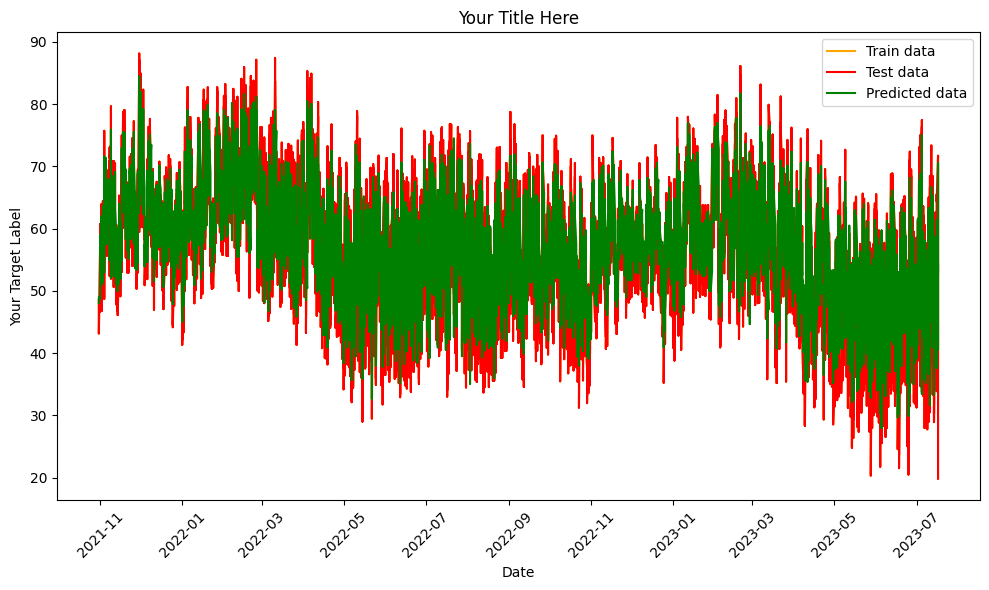

In [36]:
# Replace 'target' with the actual column name of the target variable in your dataset
#target = 'your_target_column_name'

# Assuming you have already loaded the data_df DataFrame

# Sorting the data by date
data_df = data_df.sort_values(by='Date')

# Create a new DataFrame with only the 'Date' and target columns
dfs = data_df[['Date', target]]

# Redefine num = 60 as the original value
num = 10

# Create a DataFrame with just the target column and use the date as the index
new_data = dfs.set_index('Date')

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(new_data)

# Split the data into train and test sets
train, test = train_test_split(scaled_data, test_size=0.2, shuffle=False)

# Create sequences for training data
x_train, y_train = [], []
for i in range(num, len(train)):
    x_train.append(train[i - num:i, 0])
    y_train.append(train[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=5, batch_size=64, verbose=1)

# Prepare the test data
x_test, y_test = [], []
for i in range(len(train), len(scaled_data)):
    x_test.append(scaled_data[i - num:i, 0])
    y_test.append(scaled_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Predicting 'values'
closing_price = model.predict(x_test)
closing_price = scaler.inverse_transform(closing_price)

# Calculate errors
mse = mean_squared_error(y_test, closing_price)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, closing_price)
r2 = r2_score(y_test, closing_price)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(new_data.index[-len(test):], new_data.iloc[-len(test):][target], 'orange', label='Train data')
plt.plot(new_data.index[-len(test):], scaler.inverse_transform(test), 'red', label='Test data')
plt.plot(new_data.index[-len(test):], closing_price, 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Your Title Here')  # Replace 'Your Title Here' with an appropriate title
plt.ylabel('Your Target Label')  # Replace 'Your Target Label' with the actual label name
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

## LSTM with  MinMaxScaler data 

74878/74878 - 127s - loss: 8.9976e-04 - 127s/epoch - 2ms/step
468/468 [==============================] - 1s 1ms/step


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_75403/2944037748.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = closing_price


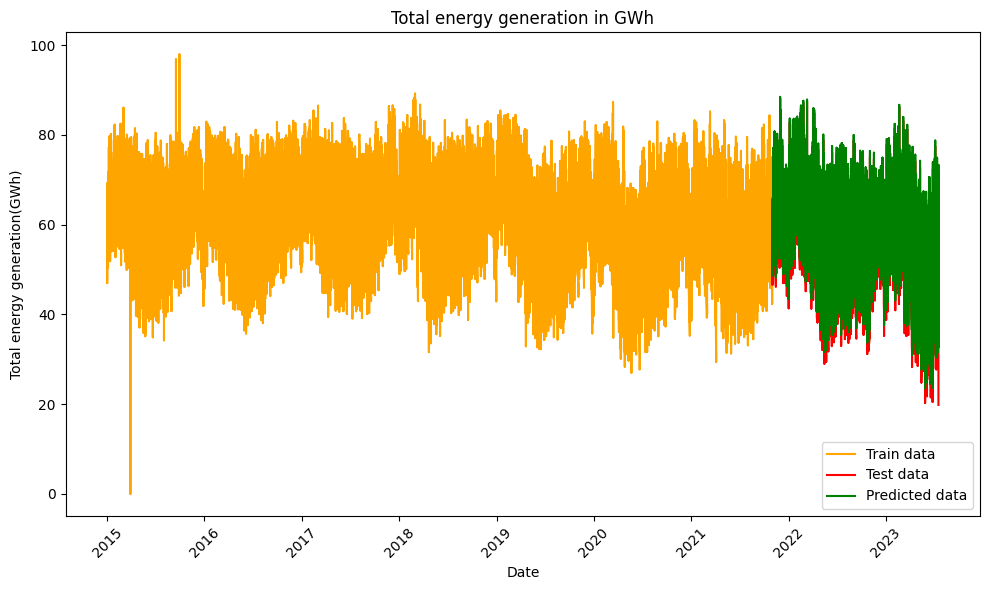

In [194]:
# 'Date' format y-m-d
 #target =  'Total_energy_generation_gwh'
dfs = data_df[['Date',  target]]
# creating dataframe
data = dfs.sort_index(ascending=True, axis=0)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
for i in range(0, len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# creating train and test sets
dataset = new_data.values

train = dataset[0:int(len(dataset) * 0.8), :]
valid = dataset[int(len(dataset) * 0.8):, :]

# converting dataset into x_train and y_train
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

x_train, y_train = [], []
for i in range(len(scaled_data)):
    if i == 0:
        continue  # Skip the first data point as we cannot create an input sequence for it
    x_train.append(scaled_data[i - 1:i, 0])
    y_train.append(scaled_data[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=1, batch_size=1, verbose=2)

# predicting 246 values, using past data from the train data
inputs = new_data[len(new_data) - len(valid) - 1:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(len(inputs)):
    if i == 0:
        continue  # Skip the first data point as we cannot create an input sequence for it
    X_test.append(inputs[i - 1:i, 0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

# for plotting
train = new_data[:int(len(dataset) * 0.8)]
valid = new_data[int(len(dataset) * 0.8):]
valid['Predictions'] = closing_price

plt.figure(figsize=(10, 6))
plt.plot(train[target], 'orange', label='Train data')
plt.plot(valid[target], 'red', label='Test data')
plt.plot(valid['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()
# valid.loc[:, 'Predictions'] = closing_price

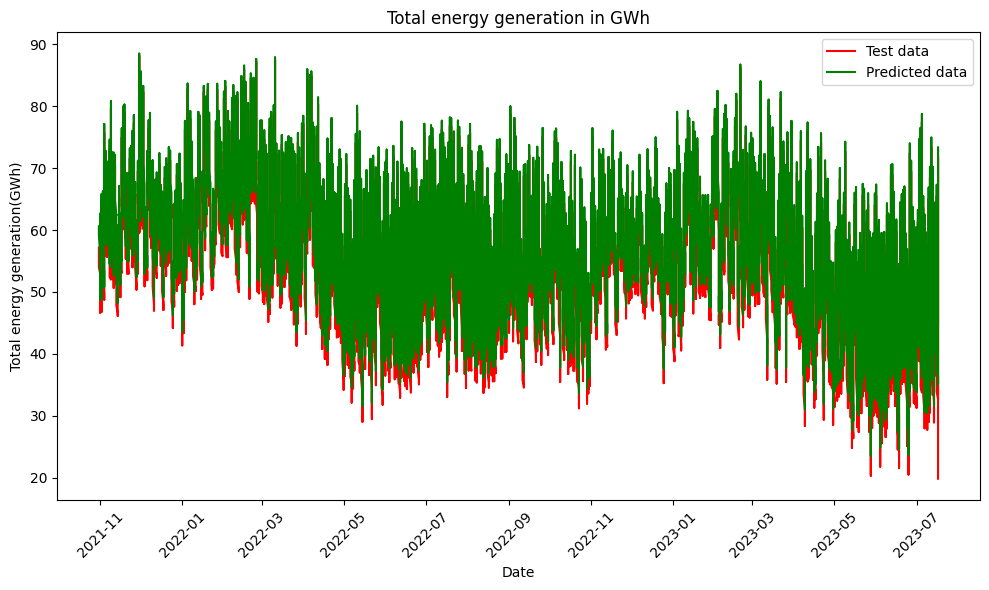

In [198]:
plt.figure(figsize=(10, 6))
#plt.plot(train[target], 'orange', label='Train data')
plt.plot(valid[target], 'red', label='Test data')
plt.plot(valid['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [196]:
#calculating score matrices and residuals
rms=np.sqrt(np.mean(np.power((valid[target]-valid['Predictions']),2)))
ms=np.mean(np.power((valid[target]-valid['Predictions']),2))
ma=np.mean(np.power((valid[target]-valid['Predictions']),1))
R2= 1-np.mean(np.power((valid[target]-valid['Predictions']),2))/(np.mean(np.power((valid[target]-np.mean(valid)),2)))

print("Root Mean Squared Error:", rms)
print("Mean Squared Error:", ms)
print("Mean Absolute Error:", ma)
print("R^2:", R2)
residuals =valid[target]-valid['Predictions']
#print("Residuals:", residuals)
#print("Score Matrices:", rms, ms, mae,R2)
#residuals = valid - closing_price
#print("Residuals:", residuals)

Root Mean Squared Error: 3.1315618605083726
Mean Squared Error: 9.806679686190659
Mean Absolute Error: -1.9575822951009108
R^2: 0.9240294610293027


In [197]:
#calculating errors
y_test = valid[target]
y_pred = valid['Predictions']#closing_price
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

Root Mean Squared Error: 3.1315618605083713
Mean Squared Error: 9.806679686190652
Mean Absolute Error: 2.686003479536782
R^2: 0.9234614147582505


## LSTM with StandardScaler

74878/74878 - 166s - loss: 0.0503 - 166s/epoch - 2ms/step
468/468 [==============================] - 2s 2ms/step


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_75403/3584308927.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = closing_price


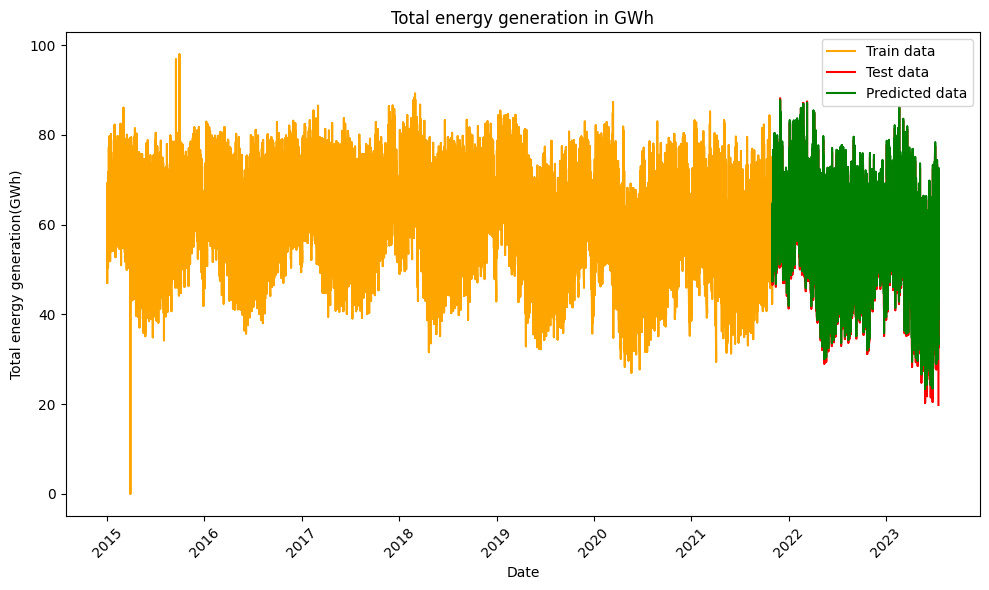

In [234]:
# 'Date' format y-m-d
dfs = data_df[['Date',  target]]
# creating dataframe
data = dfs.sort_index(ascending=True, axis=0)
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
for i in range(0, len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# creating train and test sets
dataset = new_data.values

train = dataset[0:int(len(dataset) * 0.8), :]
valid = dataset[int(len(dataset) * 0.8):, :]

# converting dataset into x_train and y_train
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

x_train, y_train = [], []
for i in range(len(scaled_data)):
    if i == 0:
        continue  # Skip the first data point as we cannot create an input sequence for it
    x_train.append(scaled_data[i - 1:i, 0])
    y_train.append(scaled_data[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=1, batch_size=1, verbose=2)

# predicting 246 values, using past data from the train data
inputs = new_data[len(new_data) - len(valid) - 1:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(len(inputs)):
    if i == 0:
        continue  # Skip the first data point as we cannot create an input sequence for it
    X_test.append(inputs[i - 1:i, 0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

# for plotting
train = new_data[:int(len(dataset) * 0.8)]
valid = new_data[int(len(dataset) * 0.8):]
valid['Predictions'] = closing_price

plt.figure(figsize=(10, 6))
plt.plot(train[target], 'orange', label='Train data')
plt.plot(valid[target], 'red', label='Test data')
plt.plot(valid['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

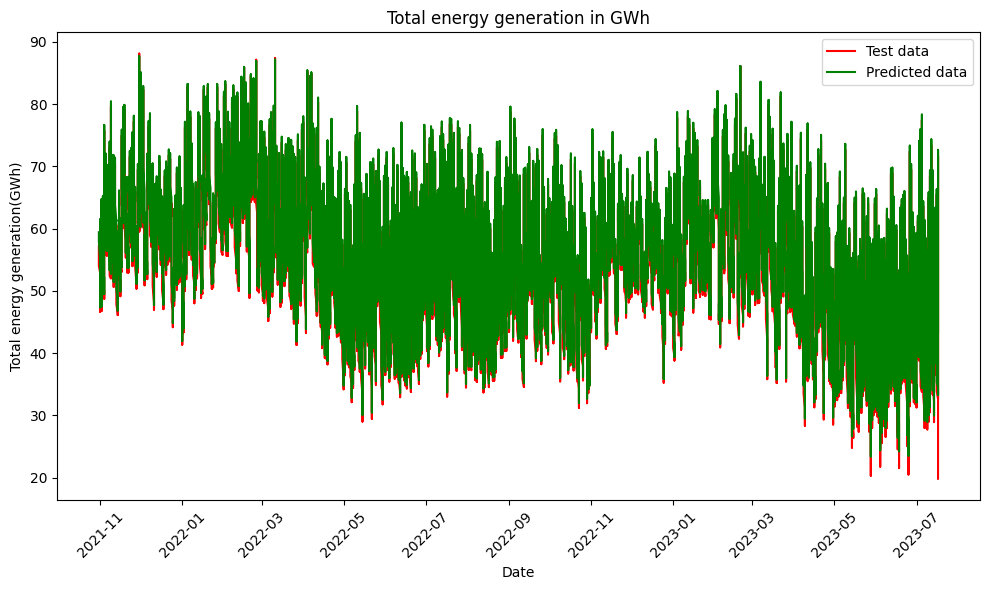

In [235]:
plt.figure(figsize=(10, 6))
#plt.plot(train[target], 'orange', label='Train data')
plt.plot(valid[target], 'red', label='Test data')
plt.plot(valid['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [236]:
#calculating score matrices and residuals
rms=np.sqrt(np.mean(np.power((valid[target]-valid['Predictions']),2)))
ms=np.mean(np.power((valid[target]-valid['Predictions']),2))
ma=np.mean(np.power((valid[target]-valid['Predictions']),1))
R2= 1-np.mean(np.power((valid[target]-valid['Predictions']),2))/(np.mean(np.power((valid[target]-np.mean(valid)),2)))

print("Root Mean Squared Error:", rms)
print("Mean Squared Error:", ms)
print("Mean Absolute Error:", ma)
print("R^2:", R2)
residuals =valid[target]-valid['Predictions']
#print("Residuals:", residuals)
#print("Score Matrices:", rms, ms, mae,R2)
#residuals = valid - closing_price
#print("Residuals:", residuals)

Root Mean Squared Error: 2.585720504471582
Mean Squared Error: 6.685950527244773
Mean Absolute Error: -0.7793191459005736
R^2: 0.9478796586021627


In [237]:
#calculating errors
y_test = valid[target]
y_pred = valid['Predictions']#closing_price
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

Root Mean Squared Error: 2.5857205044715856
Mean Squared Error: 6.685950527244792
Mean Absolute Error: 2.1298258662070984
R^2: 0.9478178944630723


## LSTM on unscale data

In [253]:
# Assuming you have already loaded data_df with 'Date' and 'target' columns
# Prepare data
# 'Date' format y-m-d
dfs = data_df[['Date', target]]
data = dfs.sort_index(ascending=True, axis=0)

# Create a new DataFrame with the same data, for easier manipulation
new_data = pd.DataFrame(index=range(0, len(dfs)), columns=['Date', target])
for i in range(0, len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# Set the 'Date' column as the index and drop the original 'Date' column
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

# Create train and test sets
dataset = new_data.values
train = dataset[0:int(len(dataset) * 0.8), :]
valid = dataset[int(len(dataset) * 0.8):, :]

# Scale the data (without unscaling, as specified)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

# Prepare the input sequences for LSTM
x_train, y_train = [], []
for i in range(len(scaled_data)):
    if i == 0:
        continue  # Skip the first data point as we cannot create an input sequence for it
    x_train.append(scaled_data[i - 1:i, 0])
    y_train.append(scaled_data[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=1, batch_size=1, verbose=2)

# Prepare the test data for predictions
inputs = new_data[len(new_data) - len(valid) - 1:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(len(inputs)):
    if i == 0:
        continue  # Skip the first data point as we cannot create an input sequence for it
    X_test.append(inputs[i - 1:i, 0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

# Add the predictions to the 'valid' DataFrame
 valid.loc[:, 'Predictions'] = closing_price
#valid['Predictions'] = closing_price

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(train[target], 'orange', label='Train data')
plt.plot(valid[target], 'red', label='Test data')
#plt.plot(valid['Predictions'], 'green', label='Predicted data')
plt.plot(valid.loc[:, 'Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.ylabel('Target Variable')
plt.title('Title Main')  # Assuming title_main is defined elsewhere
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

IndentationError: unexpected indent (2161669301.py, line 63)

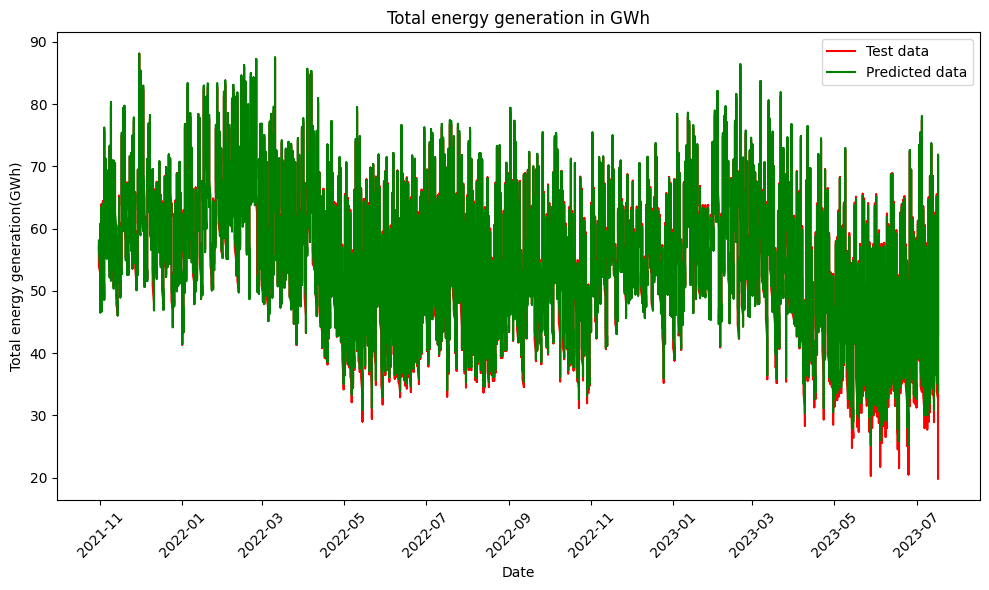

In [239]:
plt.figure(figsize=(10, 6))
#plt.plot(train[target], 'orange', label='Train data')
plt.plot(valid[target], 'red', label='Test data')
plt.plot(valid['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [240]:
#calculating score matrices and residuals
rms=np.sqrt(np.mean(np.power((valid[target]-valid['Predictions']),2)))
ms=np.mean(np.power((valid[target]-valid['Predictions']),2))
ma=np.mean(np.power((valid[target]-valid['Predictions']),1))
R2= 1-np.mean(np.power((valid[target]-valid['Predictions']),2))/(np.mean(np.power((valid[target]-np.mean(valid)),2)))

print("Root Mean Squared Error:", rms)
print("Mean Squared Error:", ms)
print("Mean Absolute Error:", ma)
print("R^2:", r2)
residuals =valid[target]-valid['Predictions']
#print("Residuals:", residuals)
#print("Score Matrices:", rms, ms, mae,R2)
#residuals = valid - closing_price
#print("Residuals:", residuals)

Root Mean Squared Error: 2.4887633338445374
Mean Squared Error: 6.193942931888976
Mean Absolute Error: 0.14020013449334695
R^2: 0.9478178944630723


In [241]:
#calculating errors
y_test = valid[target]
y_pred = valid['Predictions']#closing_price
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

Root Mean Squared Error: 2.488763333844532
Mean Squared Error: 6.193942931888951
Mean Absolute Error: 1.9503713275285868
R^2: 0.9516578858242422


## LSTM with MinMaxScaler  with fixed number of sequential time steps 

Epoch 1/20
59843/59843 - 930s - loss: 4.4231e-04 - 930s/epoch - 16ms/step
Epoch 2/20
59843/59843 - 1000s - loss: 2.2202e-04 - 1000s/epoch - 17ms/step
Epoch 3/20
59843/59843 - 974s - loss: 1.9610e-04 - 974s/epoch - 16ms/step
Epoch 4/20
59843/59843 - 1047s - loss: 1.7948e-04 - 1047s/epoch - 17ms/step
Epoch 5/20
59843/59843 - 939s - loss: 1.7082e-04 - 939s/epoch - 16ms/step
Epoch 6/20
59843/59843 - 697s - loss: 1.6304e-04 - 697s/epoch - 12ms/step
Epoch 7/20
59843/59843 - 801s - loss: 1.5806e-04 - 801s/epoch - 13ms/step
Epoch 8/20
59843/59843 - 908s - loss: 1.5508e-04 - 908s/epoch - 15ms/step
Epoch 9/20
59843/59843 - 918s - loss: 1.5090e-04 - 918s/epoch - 15ms/step
Epoch 10/20
59843/59843 - 806s - loss: 1.4740e-04 - 806s/epoch - 13ms/step
Epoch 11/20
59843/59843 - 708s - loss: 1.4495e-04 - 708s/epoch - 12ms/step
Epoch 12/20
59843/59843 - 717s - loss: 1.4182e-04 - 717s/epoch - 12ms/step
Epoch 13/20
59843/59843 - 791s - loss: 1.4043e-04 - 791s/epoch - 13ms/step
Epoch 14/20
59843/59843 - 676s

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_75403/1084579418.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = closing_price


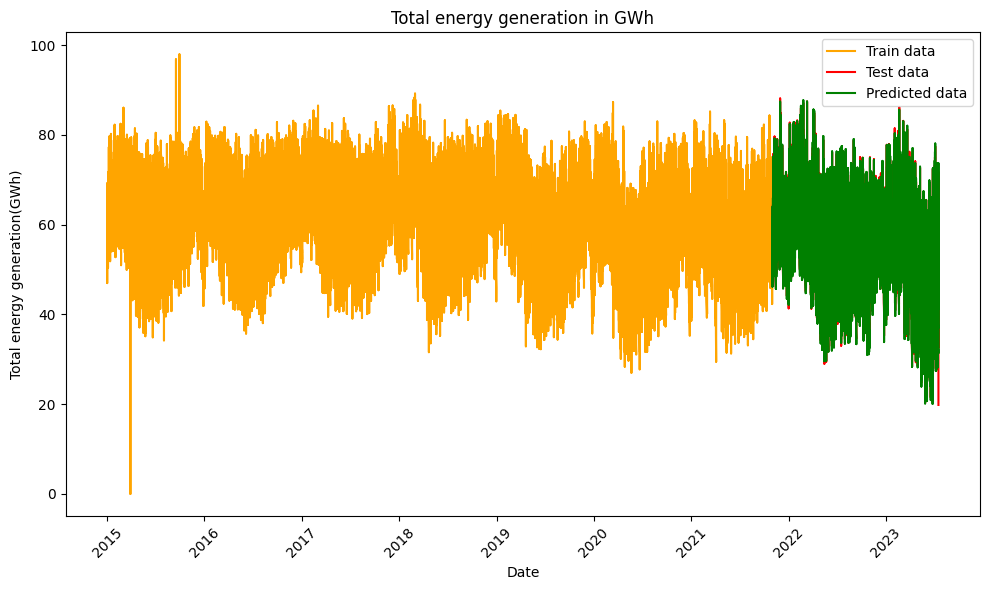

In [242]:
# 'Date' format y-m-d
dfs = data_df[['Date',  target]]
#creating dataframe
data = dfs.sort_index(ascending=True, axis=0)
new_data = pd.DataFrame(index=range(0,len(dfs)),columns=['Date', target])
for i in range(0,len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data[target][i] = data[target][i]

# Redefine num= 60 origional
#Input Sequence Length: The purpose of num is to determine the length of the input sequences that will be fed into the LSTM model during training.
num=60

#setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

#creating train and test sets
dataset = new_data.values

train = dataset[0:int(len(dataset)*0.8),:]
valid = dataset[int(len(dataset)*0.8):,:]

#converting dataset into x_train and y_train
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

x_train, y_train = [], []
for i in range(num,len(train)):
    x_train.append(scaled_data[i-num:i,0])
    y_train.append(scaled_data[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=20, batch_size=1, verbose=2)

#predicting 'values', using past 'num' from the train data
inputs = new_data[len(new_data) - len(valid) - num:].values
inputs = inputs.reshape(-1,1)
inputs  = scaler.transform(inputs)


X_test = []
for i in range(num,inputs.shape[0]):
    X_test.append(inputs[i-num:i,0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

#for plotting
train = new_data[:int(len(dataset)*0.8)]
valid = new_data[int(len(dataset)*0.8):]
valid['Predictions'] = closing_price
#plt.plot(train[target])
#plt.plot(valid[[target,'Predictions']])
#plt.show()

plt.figure(figsize=(10,6))
plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

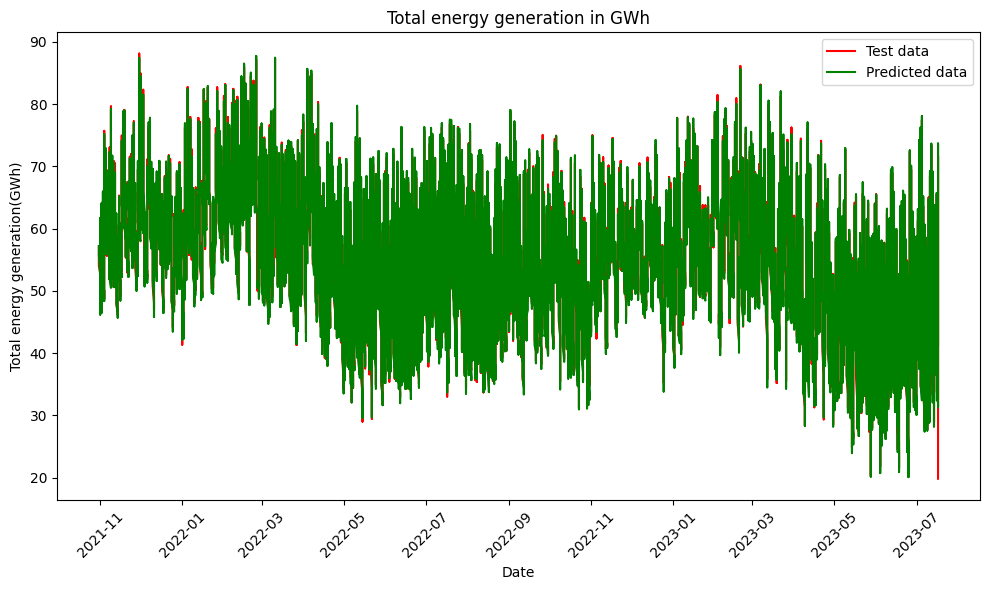

In [243]:
plt.figure(figsize=(10,6))
#plt.plot(train[target],  'orange', label='Train data')
plt.plot(valid[target],  'red', label='Test data')
plt.plot(valid['Predictions'],  'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [244]:
#calculating score matrices and residuals
rms=np.sqrt(np.mean(np.power((valid[target]-valid['Predictions']),2)))
ms=np.mean(np.power((valid[target]-valid['Predictions']),2))
ma=np.mean(np.power((valid[target]-valid['Predictions']),1))
R2= 1-np.mean(np.power((valid[target]-valid['Predictions']),2))/(np.mean(np.power((valid[target]-np.mean(valid)),2)))

print("Root Mean Squared Error:", rms)
print("Mean Squared Error:", ms)
print("Mean Absolute Error:", ma)
print("R^2:", r2)
residuals =valid[target]-valid['Predictions']
#print("Residuals:", residuals)
#print("Score Matrices:", rms, ms, mae,R2)
#residuals = valid - closing_price
#print("Residuals:", residuals)

Root Mean Squared Error: 1.1559504299590015
Mean Squared Error: 1.3362213965224008
Mean Absolute Error: -0.02018778551541839
R^2: 0.9516578858242422


In [245]:
#calculating errors
y_test = valid[target]
y_pred = valid['Predictions']#closing_price
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

Root Mean Squared Error: 1.1559504299590015
Mean Squared Error: 1.3362213965224008
Mean Absolute Error: 0.8762985464466942
R^2: 0.9895711394139247


## LSTM with StandardScaler with fixed number of sequential time steps 

In [ ]:
# 'Date' format y-m-d
# Create a new DataFrame with Date and target columns
dfs = data_df[['Date', target]]
data = dfs.sort_index(ascending=True, axis=0)

# Redefine num= 60 origional
#Input Sequence Length: The purpose of num is to determine the length of the input sequences that will be fed into the LSTM model during training.
num = 60

# Setting index
data.index = data.Date
data.drop('Date', axis=1, inplace=True)

# Create and fit the standard scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Creating train and test sets
dataset = scaled_data

train = dataset[0:int(len(dataset) * 0.8), :]
valid = dataset[int(len(dataset) * 0.8):, :]

x_train, y_train = [], []
for i in range(num, len(train)):
    x_train.append(train[i - num:i, 0])
    y_train.append(train[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=20, batch_size=1, verbose=2)

# Preparing test data for prediction
inputs = data[len(data) - len(valid) - num:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(num, inputs.shape[0]):
    X_test.append(inputs[i - num:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Predict using the LSTM model
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

# Adding the 'Predictions' column to the valid DataFrame
valid = dfs[int(len(dataset) * 0.8):]
valid['Predictions'] = closing_price

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(dfs[:int(len(dataset) * 0.8)][target], 'orange', label='Train data')
plt.plot(valid[target], 'red', label='Test data')
plt.plot(valid['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# Plotting the results
plt.figure(figsize=(10, 6))
#plt.plot(dfs[:int(len(dataset) * 0.8)][target], 'orange', label='Train data')
plt.plot(valid[target], 'red', label='Test data')
plt.plot(valid['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
#calculating score matrices and residuals
rms=np.sqrt(np.mean(np.power((valid[target]-valid['Predictions']),2)))
ms=np.mean(np.power((valid[target]-valid['Predictions']),2))
ma=np.mean(np.power((valid[target]-valid['Predictions']),1))
R2= 1-np.mean(np.power((valid[target]-valid['Predictions']),2))/(np.mean(np.power((valid[target]-np.mean(valid)),2)))

print("Root Mean Squared Error:", rms)
print("Mean Squared Error:", ms)
print("Mean Absolute Error:", ma)
print("R^2:", r2)
residuals =valid[target]-valid['Predictions']
#print("Residuals:", residuals)
#print("Score Matrices:", rms, ms, mae,R2)
#residuals = valid - closing_price
#print("Residuals:", residuals)

In [ ]:
#calculating errors
y_test = valid[target]
y_pred = valid['Predictions']#closing_price
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)

## LSTM with Unscale data with fixed number of sequential time steps 

In [ ]:
# Assuming you have 'data_df' DataFrame with columns 'Date' and 'target'
# 'Date' format y-m-d
# Create a new DataFrame with Date and target columns
dfs = data_df[['Date', 'target']]
data = dfs.sort_index(ascending=True, axis=0)

# Redefine num= 60 origional
#Input Sequence Length: The purpose of num is to determine the length of the input sequences that will be fed into the LSTM model during training.
num = 60

# Setting index
data.index = data.Date
data.drop('Date', axis=1, inplace=True)

# Create train and test sets
dataset = data.values

train = dataset[0:int(len(dataset) * 0.8), :]
valid = dataset[int(len(dataset) * 0.8):, :]

x_train, y_train = [], []
for i in range(num, len(train)):
    x_train.append(train[i - num:i, 0])
    y_train.append(train[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=20, batch_size=1, verbose=2)

# Preparing test data for prediction
inputs = data[len(data) - len(valid) - num:].values
inputs = inputs.reshape(-1, 1)

X_test = []
for i in range(num, inputs.shape[0]):
    X_test.append(inputs[i - num:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Predict using the LSTM model
closing_price = model.predict(X_test)

# Adding the 'Predictions' column to the valid DataFrame
valid = dfs[int(len(dataset) * 0.8):]
valid['Predictions'] = closing_price

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(dfs[:int(len(dataset) * 0.8)]['target'], 'orange', label='Train data')
plt.plot(valid['target'], 'red', label='Test data')
plt.plot(valid['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title('Title of the plot')  # Replace 'Title of the plot' with your desired title
plt.ylabel('Target Label')  # Replace 'Target Label' with your desired ylabel
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# Plotting the results
plt.figure(figsize=(10, 6))
#plt.plot(dfs[:int(len(dataset) * 0.8)][target], 'orange', label='Train data')
plt.plot(valid[target], 'red', label='Test data')
plt.plot(valid['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
#calculating score matrices and residuals
rms=np.sqrt(np.mean(np.power((valid[target]-valid['Predictions']),2)))
ms=np.mean(np.power((valid[target]-valid['Predictions']),2))
ma=np.mean(np.power((valid[target]-valid['Predictions']),1))
R2= 1-np.mean(np.power((valid[target]-valid['Predictions']),2))/(np.mean(np.power((valid[target]-np.mean(valid)),2)))

print("Root Mean Squared Error:", rms)
print("Mean Squared Error:", ms)
print("Mean Absolute Error:", ma)
print("R^2:", r2)
residuals =valid[target]-valid['Predictions']
#print("Residuals:", residuals)
#print("Score Matrices:", rms, ms, mae,R2)
#residuals = valid - closing_price
#print("Residuals:", residuals)

In [ ]:
#calculating errors
y_test = valid[target]
y_pred = valid['Predictions']#closing_price
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Root Mean Squared Error:", rmse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2:", r2)


- The parameter num controls the length of the input sequences used to train the LSTM model. A larger value of num would result in longer input sequences, potentially capturing more complex patterns in the data, but it could also increase the computational cost and memory requirements during training. On the other hand, a smaller value of num would result in shorter input sequences, possibly capturing simpler patterns but with reduced context information. The choice of the appropriate value for num depends on the specific dataset and the problem being addressed.

- Input Sequence Length: The purpose of num is to determine the length of the input sequences that will be fed into the LSTM model during training. Specifically, it represents the number of previous time steps to be used as input to predict the next time step.
Creating Input-Output Pairs: The code uses a sliding window approach to create input-output pairs for training the LSTM model. For each time step in the training data (from num to the end), it takes the previous num time steps as input and the next time step as the corresponding output.


- x_train and y_train: The variable x_train is a list that stores the input sequences, and y_train is a list that stores the corresponding output values (next time step). The input sequences are created by taking num time steps from the scaled data as input for each output value.
Reshaping for LSTM Input: After creating the input sequences in x_train, they are reshaped to match the expected input shape of the LSTM model. The shape of x_train is (number of samples, num, 1) where num represents the number of time steps in each input sequence, and 1 represents the number of features at each time step.

#### other details
- dfs: This is assumed to be a pandas DataFrame containing the input data. It is not explicitly defined in the provided code but is referenced in the first line: data = dfs.sort_index(ascending=True, axis=0). The DataFrame dfs is sorted by index in ascending order.
- target: This is a variable containing the name of the target column in the DataFrame dfs.
num: This variable defines the number of previous time steps to be used for creating the input sequences for the LSTM model.
- x_train and y_train: These are lists used to store the input and output sequences, respectively, for training the LSTM model.
- epochs: The number of epochs represents how many times the entire dataset is passed through the neural network during training.
- batch_size: The batch size is the number of samples propagated through the neural network before the weights are updated. In the code, the batch size is set to 1, meaning the weights are updated after each sample.
- input_shape: This parameter specifies the shape of the input data for the LSTM layer. It is set to (x_train.shape[1], 1), where x_train.shape[1] is the number of time steps in each input sequence, and 1 represents the number of features for each time step.
 - return_sequences: This parameter is used in the first LSTM layer. It determines whether to return the full sequence of hidden states for each time step or only the last one. In the code, it is set to True, which means the LSTM layer returns sequences.
- feature_range: This parameter is used in MinMaxScaler and defines the range of the transformed data. In the code, it is set to (0, 1), meaning the transformed data will be scaled between 0 and 1.
- plt.plot(): These are parameters used in the matplotlib.pyplot.plot() function for plotting the data and predictions. For example, 'orange' represents the color of the plot, 'Train data', 'Test data', and 'Predicted data' are labels for the data series, and title_main and ylable_target are strings used for the plot title and y-axis label, respectively.
- It's worth noting that some variables, such as title_main and ylable_target, are not explicitly defined in the provided code and would need to be defined elsewhere in the code for the plotting to work correctly. Additionally, new_data is used for data manipulation and as the DataFrame for plotting the predictions.

In [ ]:
# 'Date' format y-m-d
# Create a new DataFrame with Date and target columns
dfs = data_df[['Date', target]]
data = dfs.sort_index(ascending=True, axis=0)

# Redefine num to 60
num = 60

# Setting index
data.index = data.Date
data.drop('Date', axis=1, inplace=True)

# Normalize data
data_mean = data.mean()
data_std = data.std()
data = (data - data_mean) / data_std

# Creating train and test sets
dataset = data.values

train = dataset[0:int(len(dataset) * 0.8), :]
valid = dataset[int(len(dataset) * 0.8):, :]

x_train, y_train = [], []
for i in range(num, len(train)):
    x_train.append(train[i - num:i, 0])
    y_train.append(train[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=20, batch_size=1, verbose=2)

# Preparing test data for prediction
inputs = data[len(data) - len(valid) - num:].values
inputs = (inputs - data_mean) / data_std

X_test = []
for i in range(num, inputs.shape[0]):
    X_test.append(inputs[i - num:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Predict using the LSTM model
closing_price = model.predict(X_test)
closing_price = closing_price * data_std + data_mean

# Adding the 'Predictions' column to the valid DataFrame
valid = dfs[int(len(dataset) * 0.8):]
valid['Predictions'] = closing_price

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(dfs[:int(len(dataset) * 0.8)][target], 'orange', label='Train data')
plt.plot(valid[target], 'red', label='Test data')
plt.plot(valid['Predictions'], 'green', label='Predicted data')
plt.xlabel('Date')
plt.title(title_main)
plt.ylabel(ylable_target)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()